<a href="https://colab.research.google.com/drive/11yMT1nHD38Quuzc_tcJgixjUbOVY1Jmm?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CE 400/500: AI for Chemical Engineers
# Hands-on: Classification with Decision Trees and Random Forests for Chemical Process Fault Detection
Instructor: Kaihang Shi, Assistant Professor of Chemical & Biological Engineering at the University at Buffalo

**Learning objectives:**
- Perform classification task using a process dataset.
- Build decision tree and random forest classifiers for binary fault detection.
- Perform hyperparameter tuning and evaluate with multiple metrics.
- Visualize a decision tree and interpret random forest via feature importance.

**References for the Eastman dataset:**
- [Tennessee Eastman Process data description from MLCE course](https://edgarsmdn.github.io/MLCE_book/08_PCA.html#id17:~:text=.show()-,Tennessee%20Eastman%20process,-%F0%9F%8F%AD%23)
- James J Downs and Ernest F Vogel. A plant-wide industrial process control problem. Computers & chemical engineering, 17(3):245–255, 1993.
- Evan L. Russell, Leo H. Chiang, and Richard D. Braatz. Data-driven Methods for Fault Detection and Diagnosis in Chemical Processes. Springer London, 2000.

**Reference & further readings for ML:**
- [scikit-learn: Decision Trees](https://scikit-learn.org/stable/modules/tree.html)
- [What is a Decision Tree? - IBM](https://www.ibm.com/think/topics/decision-trees)
- [scikit-learn: Random Forests](https://scikit-learn.org/stable/modules/ensemble.html#forests-of-randomized-trees)
- [Class-imbalanced datasets](https://developers.google.com/machine-learning/crash-course/overfitting/imbalanced-datasets)
- Aurélien Géron, Hands-on Machine Learning with Scikit-Learn, Keras & TensorFlow, Chapter 3 - Classification.

## 1. Dataset



### 1.1 Overview of the Tennessee Eastman Process Dataset 🏭
The case-study that we are going to use is the called Tennessee Eastman process (TEP; Downs et al, [1993]). The data collected here corresponds to simulated data and it is widely used in the process monitoring community. Initially, TEP was created by the company [Eastman](https://www.eastman.com/en) to provide a realistic scenerario in which to test different process monitoring methods.

In the following we will provide a short explanation of the process. If you like to have a more detailed explanation overall read Chapter 8 of Russell et al. (2000).


The process consist of five major units:

*   Reactor
*   Condenser
*   Compressor
*   Separator
*   Stripper

and it contains eight components: the gaseous reactants $A$, $C$, $D$ and $E$ that are fed into the reactor along the inert $B$ to produce the liquids $G$ and $H$. The product $F$ is an unwanted byproduct.

$$
A(g) + C(g) + D(g) → G(liq)
$$

$$
A(g) + C(g) + E(g) → H(liq)
$$

$$
A(g) + E(g) → F(liq)
$$

$$
3D(g) → 2F(liq)
$$

The reactor product stream is then cooled using the condenser and fed to a flash separator. A recycle is implemented via the compressor with the necessary purge to prevent accumulation of $B$ and $F$. Finally, the liquid outlet of the separator is fed into a stripper for further separation. See the figure below for a schematic reresentation of the flowsheet.

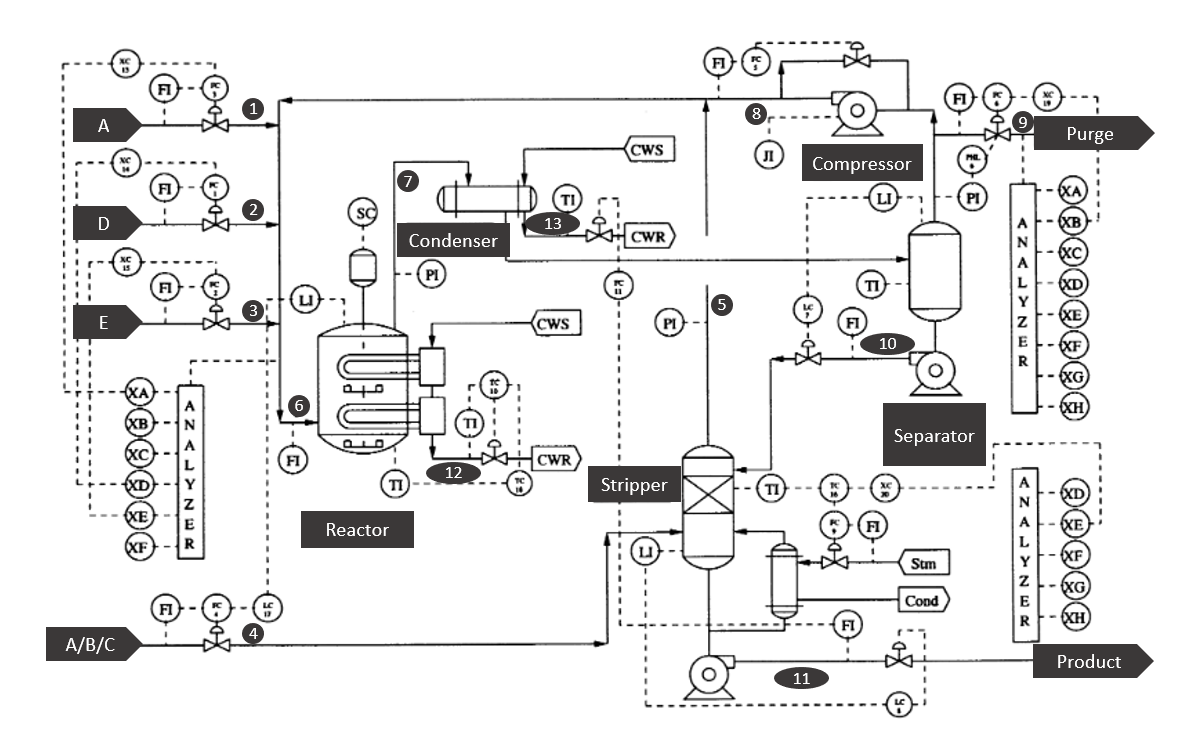



The dataset contains 41 measured states and 11 manipulated variables. Some variables are sampled every 3 minutes, 6 minutes or 15 minutes. And all measurements include Gaussian noise.

The data contains 21 faults, out of which 16 are known (Faults 1-15 and 21). Some faults are caused by step changes in some process variables, while others are associated with a random variability increase. A slow drift in the reaction kinetics and sticking valves are other causes of the faults.

### 1.2 Process Faults (Labels)

Let's import the data corresponding to the 21 faulty simulations (i.e., files 01 to 21) and the data for the normal operation (i.e., files with 00) using some for-loops and store it into a dictionary.


File | Description                                            | Type
---- | ------------------------------------------------------ | ----
00   | Normal operation                                       |
01   | A/C Feed Ratio, B Composition Constant (Stream 4)      | Step
02  | B Composition, A/C Ratio Constant (Stream 4)            | Step
03  | D Feed Temperature (Stream 2)                           | Step
04  | Reactor Cooling Water Inlet Temperature                 | Step
05  | Condenser Cooling Water Inlet Temperature               | Step
06  | A Feed Loss (Stream 1)                                  | Step
07  | C Header Pressure Loss - Reduced Availability (Stream 4)| Step
08  | A, B, C Feed Composition (Stream 4)                     | Random Variation
09  | D Feed Temperature (Stream 2)                           | Random Variation
10 | C Feed Temperature (Stream 4)                            | Random Variation
11 | Reactor Cooling Water Inlet Temperature                  | Random Variation
12 | Condenser Cooling Water Inlet Temperature                | Random Variation
13 | Reaction Kinetics                                        | Slow Drift
14 | Reactor Cooling Water Valve                              | Valve Sticking
15 | Condenser Cooling Water Valve                            |Valve Sticking
16 | Unknown
17 | Unknown
18 | Unknown
19 | Unknown
20 | Unknown
21 | Unknown



Let's load the data. The data has already being splitted into training and test.

In [ ]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

# set a random seed for reproducibility
np.random.seed(42)

data_dict = {}
for i in tqdm(range(22)):
  i_str = str(i)
  if len(i_str) == 1:
    term = '0'+i_str
  else:
    term = i_str
  for split in ['','_te']:
    term_split = term + split
    # get data from URL link
    data_dict[term_split] = np.loadtxt('https://raw.githubusercontent.com/edgarsmdn/MLCE_book/main/references/d'
                               + term_split + '.dat')

# normal operational data needs to be transposed to have the standard shape
#    where rows are samples and columns are features and labels
data_dict['00'] = data_dict['00'].T



In [ ]:
print(data_dict.keys())
print(data_dict['00'].shape)
print(data_dict['00_te'].shape)

### 1.3 Process Variables
Each dataset is reported in the form of a matrix where the 52 columns correspond to the 41 process measurements + 11 manipulated variables according to the following tables

**Process Measurements (3 minutes)**

Column | Description                         | Unit
------ | ----------------------------------- | ----
1      | A Feed  (stream 1)                  | kscmh
2      | D Feed  (stream 2)                  | kg/hr
3      | E Feed  (stream 3)                  | kg/hr
4      | A and C Feed  (stream 4)            | kscmh
5      | Recycle Flow  (stream 8)            | kscmh
6      | Reactor Feed Rate  (stream 6)       | kscmh
7      | Reactor Pressure                    | kPa gauge
8      | Reactor Level                       | %
9      | Reactor Temperature                 | Deg C
10     | Purge Rate (stream 9)               | kscmh
11     | Product Sep Temp                    | Deg C
12     | Product Sep Level                   | %
13     | Prod Sep Pressure                   | kPa gauge
14     | Prod Sep Underflow (stream 10)      | m3/hr
15     | Stripper Level                      | %
16     | Stripper Pressure                   | kPa gauge
17     | Stripper Underflow (stream 11)      | m3/hr
18     | Stripper Temperature                | Deg C
19     | Stripper Steam Flow                 | kg/hr
20     | Compressor Work                     | kW
21     | Reactor Cooling Water Outlet Temp   | Deg C
22     | Separator Cooling Water Outlet Temp | Deg C

**Reactor feed analysis (6 minutes)**

Column | Description | Unit
------ | ----------- | ----
23     | Component A | % mol
24     | Component B | % mol
25     | Component C | % mol
26     | Component D | % mol
27     | Component E | % mol
28     | Component F | % mol

**Purge gas analysis (6 minutes)**

Column | Description | Unit
------ | ----------- | ----
29     | Component A | % mol
30     | Component B | % mol
31     | Component C | % mol
32     | Component D | % mol
33     | Component E | % mol
34     | Component F | % mol
35     | Component G | % mol
36     | Component H | % mol

**Product analaysis (15 minutes)**

Column | Description | Unit
------ | ----------- | ----
37     | Component D | % mol
38     | Component E | % mol
39     | Component F | % mol
40     | Component G | % mol
41     | Component H | % mol

**Manipulated variables**

Column | Description
------ | -----------
42     | D Feed Flow (stream 2)            
43     | E Feed Flow (stream 3)            
44     | A Feed Flow (stream 1)        
45     | A and C Feed Flow (stream 4)
46     | Compressor Recycle Valve
47     | Purge Valve (stream 9)
48     | Separator Pot Liquid Flow (stream 10)
49     | Stripper Liquid Product Flow (stream 11)
50     | Stripper Steam Valve
51     | Reactor Cooling Water Flow
52     | Condenser Cooling Water Flow

For instance, let's observe the profile under normal conditions of the reactor pressure (7th variable)

In [ ]:
from matplotlib import pyplot as plt

var = 7
plt.plot(data_dict['00'][:,var-1])
plt.xlabel('Sample')
plt.ylabel('Reactor pressure (kPa)')
plt.title('Normal operation')
plt.ylim(2680, 2730)
plt.xlim(0,500)

If you observe, during normal operation the reactor pressure is kept around 2750 kPa.

Let's compare this to the profile under faulty conditions caused by an step change in the composition of the inert species $B$ in the inlet stream (Fault 02).

In [ ]:
var = 7
plt.plot(data_dict['02'][:,var-1])
plt.xlabel('Sample')
plt.ylabel('Reactor pressure (kPa)')
plt.title('Faulty operation')
plt.ylim(2680, 2730)
plt.xlim(0,500)

The disturbance is apparent! The pressure in the reactor increases and then slowly comes back due to the control system that it has. This univariate method for process monitoring is closely related to the so-called [Shewhart charts](https://en.wikipedia.org/wiki/Shewhart_individuals_control_chart).


However, this method ignore the correlation between the process variables. In other words, some faults required the use of multivariate statistics because the fault might not become evident in the univariate cases of all process variables (i.e., all process variables individually might appear to be within normal ranges), but rather in the combination of several of them.

### 1.4 Binary Fault Detection Data Preparation

In this task, let's see if we can use tree-based ML models to classify the normal and faulty operations using process variables.

Let's prepare a binary classification dataset, where normal process is labeled as "0" (negative), and faulty process is labeled as "1" (positive).

In [ ]:
# Prepare train and test set for normal condition, add label (last colomn) "0" for normal
data_dict['normal_train'] = np.hstack((data_dict['00'], np.zeros((data_dict['00'].shape[0], 1))))
data_dict['normal_test'] = np.hstack((data_dict['00_te'], np.zeros((data_dict['00_te'].shape[0], 1))))

# Prepare train and test set for faulty conditions (use 50% of rows from each file)
faulty_train_data = []
faulty_test_data = []
rng = np.random.RandomState(42)  # reproducible sampling

for i in range(1, 22):
    term = f"{i:02d}"
    arr_train = data_dict[term]
    arr_test = data_dict[term + '_te']

    # take 50% of data for demo purposes (making training/evaluation faster later)
    n_train = arr_train.shape[0] // 2
    n_test = arr_test.shape[0] // 2

    # sample row indices without replacement
    idx_train = rng.choice(arr_train.shape[0], size=n_train, replace=False)
    idx_test = rng.choice(arr_test.shape[0], size=n_test, replace=False)

    sampled_train = arr_train[idx_train, :]
    sampled_test = arr_test[idx_test, :]

    # add label column = 1 for faulty
    faulty_train_data.append(np.hstack((sampled_train, np.ones((sampled_train.shape[0], 1)))))
    faulty_test_data.append(np.hstack((sampled_test, np.ones((sampled_test.shape[0], 1)))))

data_dict['faulty_train'] = np.vstack(faulty_train_data)
data_dict['faulty_test'] = np.vstack(faulty_test_data)

# Now let's first check the number of positive and negative samples
print('Normal train samples:', data_dict['normal_train'].shape[0])
print('Faulty train samples:', data_dict['faulty_train'].shape[0])
print('Normal test samples:', data_dict['normal_test'].shape[0])
print('Faulty test samples:', data_dict['faulty_test'].shape[0])

Obviously, our dataset is **class-imbalanced**.

In a **class-balanced** dataset, the number of positive classes and negative classes is about equal. In a **class-imbalanced** dataset, one label is considerably more common than the other.

In the real world, class-imbalanced datasets are far more common than class-balanced datasets. For example, in a dataset of credit card transactions, fraudulent purchases might make up less than 0.1% of the examples. Similarly, in a medical diagnosis dataset, the number of patients with a rare virus might be less than 0.01% of the total examples. In a class-imbalanced dataset:
* The more common label is called the majority class.
* The less common label is called the minority class.

Tree-based models in `sklearn` package support class weighting to account for imbalance. We will come back to this point later.

For now, let's get our training and test sets ready:

In [ ]:
# Combine normal and faulty data into pandas DataFrames
df_train = pd.DataFrame(np.vstack((data_dict['normal_train'], data_dict['faulty_train'])))
df_test = pd.DataFrame(np.vstack((data_dict['normal_test'], data_dict['faulty_test'])))

In [ ]:
df_train

In [ ]:
df_test

Let's check null entries and duplicate rows

In [ ]:
print(df_train.isnull().sum())
print(f"Number of duplicate rows for training: {df_train.duplicated().sum()}")


In [ ]:
# Split features and labels
X_train = df_train.iloc[:, :-1]
y_train = df_train.iloc[:, -1]
X_test = df_test.iloc[:, :-1]
y_test = df_test.iloc[:, -1]

**Note:** Tree-based models (Decision Trees, Random Forests) are scale-invariant: they split on feature thresholds and do not require normalization.

## 2. Decision Tree

### 2.1 Overview
A decision tree is a simple yet powerful machine learning model used for both classification and regression tasks. It works by recursively splitting the dataset into smaller groups based on feature values, forming a tree-like structure:

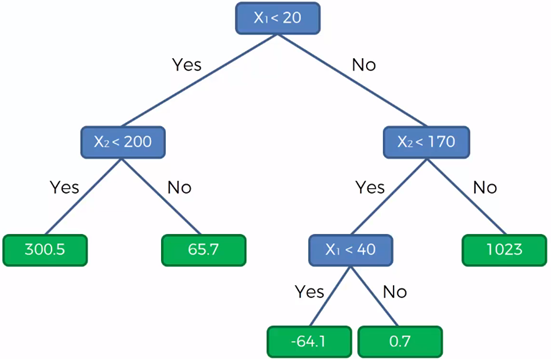

* Root and branch (or internal) nodes represent questions about a feature (e.g., "Is feature X1< 20?").
* Branches represent the possible answers (Yes/No).
* Leaf (or terminal) nodes represent the final predictions (a class label or a numerical value).
* The algorithm chooses splits that best separate the data, i.e., such that the samples with the same labels or similar target values are grouped together in the same node.
* The quality of a candidate split of node is evaluted using an impurity function or loss function, e.g., Gini impurity, entropy, or variance reduction, the choice of which depends on the task being solved (classification or regression).
* This process continues until the tree reaches a stopping condition (such as maximum depth or minimum samples per leaf).



Decision trees have several **hyperparameters** that control tree growth, complexity, and randomness. The full list of hyperparameters is available on [scikit-learn website](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html). Here we focus on several important hyperparameters that usually require tuning:

* `max_depth`: Maximum depth of the tree. This parameter can prevent overfitting by limiting how “deep” the tree can grow.  
* `min_samples_split`: Minimum number of samples required to split a node.  
* `min_samples_leaf`: Minimum number of samples required in a leaf node. This parameter and `min_samples_split` prevent overly small, noisy leaves.
* `max_leaf_nodes`: Maximum number of leaf nodes.  
* `max_features`: Number of features to consider when looking for best split. It controls randomness and diversity (especially in ensembles like random forest).  

### 2.2 Details on Loss and Training Algorithm
For classification task, Gini impurity $H$ for node $m$ is:

$$
H_m = \sum_k p_{mk} (1 - p_{mk})
$$

where $p_{mk}$ is the probability (fraction) of class $k$ in the node $m$. The minimum Gini impurity is 0 (pure node with one class), and it reaches its maximum when the classes are equally mixed (e.g., 0.5 for two classes equally probable).

Suppose we split a parent node $m$ into two child nodes: left ($L$) and right ($R$).

- Let $N_m$ = number of samples in parent node $m$  
- Let $N_L, N_R$ = number of samples in child nodes $L$ and $R$  
- Let $H_L, H_R$ = Gini impurities of the child nodes  

The weighted impurity after the split is:

$$
H_{\text{split}} = \frac{N_L}{N_m} H_L \;+\; \frac{N_R}{N_m} H_R
$$

The reduction in impurity (a.k.a. Gini gain) is:

$$
\Delta H = H_m - H_{\text{split}}
$$


For decision tree training:

- For each candidate split (feature + threshold), compute $H_{\text{split}}$.  
- Choose the split with the largest $\Delta H$.  
- Repeat recursively until a stopping condition (e.g., max depth, min samples, or pure nodes).


### 2.3 A Quick Start
Now let's train a decision tree model using `sklearn` package with example hyperparameters (for demo only).

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Train a Decision Tree classifier with example/default hyperparameters
dt = DecisionTreeClassifier(criterion='gini', # default
                            max_depth=4, # example value, limit the depth to 4 for visualization purpose
                            min_samples_split=2, # default, a node must have at least two samples to be split
                            min_samples_leaf=1, # default, a leaf must have at least one sample
                            max_features=None, # default, use all features
                            random_state=42, # example value for reproducibility
                            max_leaf_nodes=None, # default, unlimited number of leaf nodes

                            # example value, handle class imbalance by adjusting weights inversely proportional to class frequencies;
                            # it basically means replicating the smaller class until you have as many samples as in the larger one, but in an implicit way.
                            class_weight= 'balanced'
                            )
dt.fit(X_train, y_train)

Let's visualize our trained decision tree:

In [ ]:
from sklearn.tree import plot_tree, export_text

# feature names (so index starts from 1 and corresponds to those in table in Sec. 1.3)
feature_names = [f'var_{i+1}' for i in range(X_train.shape[1])]

# Plot the tree (adjust figsize / fontsize as needed)
plt.figure(figsize=(18, 8))
plot_tree(dt,
          feature_names=feature_names,
          class_names=['normal', 'faulty'],
          filled=True,
          rounded=True,
          proportion=True,
          fontsize=10)
plt.title('Decision Tree (trained model: dt)')
plt.tight_layout()
plt.show()

### 2.4 Evaluation Using Classification Metrics
Let's recap the evaluation metrics for classification tasks we have introduced in the lecture:

| Metric              | Formula                                | Guidance |
|---------------------|----------------------------------------|----------|
| **Accuracy**        | (TP + TN) / (TP + TN + FP + FN)        | • Use as a rough indicator of model training progress/convergence for balanced datasets.<br>• For model performance, use only in combination with other metrics.<br>• Avoid for **imbalanced datasets**. Consider using another metric. |
| **Recall (True positive rate)** | TP / (TP + FN) | Use when false negatives (e.g., misclassified faulty process) are more expensive than false positives (e.g., misclassified normal process). |
| **False positive rate** | FP / (FP + TN) | Use when false positives are more expensive than false negatives. |
| **Precision**       | TP / (TP + FP)                         | Use when it’s very important for positive predictions to be accurate. |
| **F1 Score**        | 2 × (Precision × Recall) / (Precision + Recall) | Use when you need a balance between Precision and Recall, especially with **imbalanced datasets**. |


Let's evaluate recall, precision, and F1 score of the trained decision tree model:

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# predict
y_pred = dt.predict(X_test)

# compute metrics for positive class = faulty (label 1)
precision_pos = precision_score(y_test, y_pred, pos_label=1)
recall_pos = recall_score(y_test, y_pred, pos_label=1)
f1_pos = f1_score(y_test, y_pred, pos_label=1)

print(f"Faulty (positive, label=1) — precision: {precision_pos:.4f}, recall: {recall_pos:.4f}, F1: {f1_pos:.4f}")


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (rows=true, cols=pred):")
print(cm)

# print number of labels in text set
print('Number of normal samples in test set:', np.sum(y_test == 0))
print('Number of faulty samples in test set:', np.sum(y_test == 1))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['normal', 'faulty'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()



- Number of instance in confusion matrix match the actual number of positive and negative samples.
- Many actual faulty process is misclassified as normal, leading to low recall value.
- Note that we did not tune the hyperparameter of the decision tree.

Let's use random forest to improve our detection!

## 3. Random Forest


### 3.1 Overview
Random Forests reduce overfitting by averaging many de-correlated (independent) decision trees. They usually outperform a single decision tree and provide robust feature importance estimates.

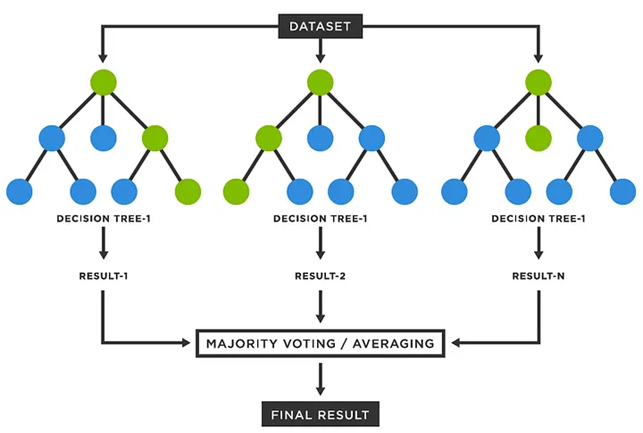

In addition to the hyperparameters mentioned in Sec. 2.1, random forest model include the following additional important hyperparameters:

- `n_estimators`: Number of trees in the forest (more trees generally improve performance but increase training time).
- `bootstrap`: Whether bootstrap samples are used when building trees (default True).

For a full list of hyperparameters for random forest classifier, see [scikit-learn website](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

### 3.2 Hyperparameter Tuning Using 3-Fold Cross Validation
As a rule of thumb, following hyperparameters are usually important:

Tree-based parameters:
* `max_depth`: Maximum depth of the tree. This parameter can prevent overfitting by limiting how “deep” the tree can grow.  
* `min_samples_leaf`: Minimum number of samples required in a leaf node.
* `max_features`: Number of features to consider when looking for best split.

Forest-based parameters:
- `n_estimators`: Number of trees in the forest

We will search optimal hyperparameters using 3-fold cross validation.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold

# initialize a random forest classifier
rf = RandomForestClassifier(class_weight='balanced',    # handle class imbalance
                            random_state=42,            # for reproducibility
                            n_jobs=-1                   # use all CPU cores
                            )

# Parameter distributions to search
param_dist = {
    # here I narrow down the search space to accelerate the CV (3x2x2x2 = 24 combinations)
    'n_estimators': [200, 400, 500],
    'max_depth': [30, 40],
    'min_samples_leaf': [1, 4],
    'max_features': [0.2, 0.5]
}

# 3-fold CV (shuffle for robustness)
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Randomized search (faster than exhaustive grid search, gridsearchcv); optimize F1 for the positive (faulty) class
rs = RandomizedSearchCV(
    estimator=rf,            # the model to tune
    param_distributions=param_dist,  # hyperparameter space
    n_iter=10,               # number of random combinations to try, you can pick a larger number for trial test.
    scoring='f1',            # optimize F1 for the positive class by default
    cv=cv,                   # cross-validation scheme
    verbose=2,               # verbosity level (0=silent, 1=some, 2=more)
    random_state=42,
    n_jobs=-1,               # use all CPU cores
    refit = True            # default, refit the best model on the whole training set
                            #  (so no need to fit the model again after hyperparameter search)
)

# Run search on the training set (X_train, y_train are available in the notebook)
rs.fit(X_train, y_train)

# Best estimator and parameters (assign to best_rf for downstream cells)
best_rf = rs.best_estimator_

print("Best CV score (F1):", rs.best_score_)
print("Best hyperparameters:")
for k, v in rs.best_params_.items():
    print(f"  {k}: {v}")

### 3.3 Evaluation of the Best RF Model
The best estimator from the randomized search is already refit on the full training set (default `refit=True`).

Let's use our evaluation code from decision tree (Sec. 2.4):

In [ ]:
# Evaluate the best random-forest model found by RandomizedSearchCV
y_pred_rf = best_rf.predict(X_test)

precision_rf = precision_score(y_test, y_pred_rf, pos_label=1)
recall_rf = recall_score(y_test, y_pred_rf, pos_label=1)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)

print(f"Random Forest (best CV) — precision: {precision_rf:.4f}, recall: {recall_rf:.4f}, F1: {f1_rf:.4f}")

# Confusion matrix and plot
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion matrix (rows=true, cols=pred):")
print(cm_rf)
print('Number of normal samples in test set:', np.sum(y_test == 0))
print('Number of faulty samples in test set:', np.sum(y_test == 1))

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['normal', 'faulty'])
disp_rf.plot(cmap='Blues')
plt.title('Confusion Matrix — Random Forest (Best CV)')
plt.show()


Let's compare decision tree and random forest results:

| Model            | Precision | Recall | F1 Score |
|------------------|-----------|--------|----------|
| Decision Tree    | 0.9568    | 0.5318 | 0.6837   |
| Random Forest    | 0.9192    | 0.9413 | 0.9301   |


We noticed FP instances increases, we could do the following to improve the model further:

- Adjust the decision threshold: Increase the probability cutoff (e.g., from 0.5 → 0.6–0.7) so the model only predicts “positive” when it is more confident → fewer false positives.

- Use precision-oriented optimization: During hyperparameter search, score with precision, so the model prioritizes avoiding false positives.

### 3.4 Model Interpretation: Feature Importance
Understanding feature importance is crucial because it helps us interpret the model and gain insights by connecting the model’s decisions back to real-world meaning. Random Forests provide several ways to measure feature importance, i.e., which input variables most influence the model’s predictions. The two common methods are:

1. **Impurity-based importance** (Mean Decrease in Impurity, MDI): Calculated during training by looking at how much each feature reduces the impurity (e.g., Gini impurity) across all the trees.
   
2. **Permutation importance** (Mean Decrease in Accuracy, MDA): Calculated after training by randomly shuffling a feature’s values and observing how much the model performance drops. A large drop indicates that the feature was important.

Among these, impurity-based importance is computed by default in scikit-learn and is efficient because it is collected during tree construction.  


For impurity-based importance, when a feature is used to split a node, we can measure how much the impurity decreases (parent impurity – weighted average of child impurities).

- The **importance of a feature in one tree** is the sum of impurity decreases it contributed, weighted by the number of samples that reached each node.

- The **importance of a feature in the forest** is then the average of its importance across all trees.

In short: features that consistently yield large reductions in Gini impurity across many trees are considered more important.  

Now let's compute and plot impurity-based (MDI) feature importances for the trained Random Forest.

In [ ]:
# get impurity-based importances
importances = best_rf.feature_importances_
imp_series = pd.Series(importances, index=feature_names)

# sort descending
imp_sorted = imp_series.sort_values(ascending=False)

# plot top 10 features
top_n = 10
plt.figure(figsize=(8, max(4, 0.3 * top_n)))
imp_sorted.head(top_n).sort_values().plot(kind='barh', color='C0')
plt.xlabel('Importance (Mean decrease in impurity)')
plt.title(f'Top {top_n} Feature Importances (impurity-based)')
plt.tight_layout()
plt.show()

# (Optional) show cumulative importance to assess coverage
cum_imp = imp_sorted.cumsum()
print("\nCumulative importance of top features:")
print(cum_imp.head(15).to_string())

Top 3 important features are: "Reactor Cooling Water Flow", "Stripper Temperature", and "Stripper Steam Flow".

- Reactor Cooling Water Flow: This is the main handle for removing heat from the highly exothermic reactor, so any fault that changes reaction conditions shows up quickly in the cooling water demand.

- Stripper Temperature: The column temperature reflects the separation balance; changes in feed or upstream conversion shift this temperature in distinctive ways, making it a good fault indicator.

- Stripper Steam Flow: Steam flow drives the reboiler duty, and the control system adjusts it to compensate for disturbances, so its movements carry a clear signature of many faults.

We can visualize reactor cooling water flow to give us confidence.

In [ ]:
import matplotlib.pyplot as plt

# Reactor Cooling Water Flow is column 51 (index 50)
var_index = 50
variable_name = 'Reactor Cooling Water Flow'

plt.figure(figsize=(12, 8))

# Plot normal operation (test set)
plt.plot(data_dict['00_te'][:, var_index], label='Normal operation (00_te)', color='blue')

# Plot all faulty operations (test sets)
faulty_test_keys = [key for key in data_dict.keys() if key.endswith('_te') and key != '00_te']

for faulty_key in faulty_test_keys:
    plt.plot(data_dict[faulty_key][:, var_index], label=f'Faulty operation ({faulty_key})', alpha=0.7)


plt.xlabel('Sample')
plt.ylabel(f'{variable_name}')
plt.title(f'{variable_name} Profile: Normal vs. All Faulty Operations (Test Set)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()